In [1]:
# Import necessary libraries for data processing, visualization, and geospatial analysis
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np  # Redundant import (already imported above)
import ultraplot as uplt  # Custom plotting library
import xarray as xr  # For working with labeled multi-dimensional arrays
import cartopy.crs as ccrs  # For geographic projections
import pandas as pd
import geopandas as gpd  # For working with geospatial data
from shapely.geometry import shape  # For geometric operations
from rasterio.features import shapes  # For raster to vector conversion
from affine import Affine  # For affine transformations
from rasterio.features import rasterize  # For vector to raster conversion
from rasterio.features import geometry_mask  # For creating masks from geometries
import xarray as xr  # Redundant import (already imported above)
import cartopy.feature as cfeature  # For map features
from numpy import ma  # For masked arrays
from scipy.interpolate import interp1d  # For interpolation
from matplotlib.colors import Normalize  # For color normalization
import matplotlib.patches as mpatches  # For custom legend elements
import matplotlib.lines as mlines  # For custom legend lines
from matplotlib.legend_handler import HandlerLine2D  # For custom legend handlers
import rasterio  # For geospatial raster data
import rioxarray  # For xarray with rasterio capabilities

# Configure ultraplot style settings
uplt.rc.style='seaborn-v0_8-paper'  # Set plot style
uplt.rc.update({
    'tick.len': 2.0,  # Set tick length
    'tick.dir': 'in',  # Set tick direction (inward)
    'font.largesize': 12,  # Set large font size
    'font.smallsize': 10  # Set small font size
})

# Load pre-processed data (commented out - path to numpy array file)
# eg_upwind_masked=np.load('/Net/Groups/BGI/scratch/fhuang/sm_utb_cnn/model/c3d-gam/567_568_569/eg_upwind_masked_0.001.npy',)

In [2]:
rec=np.load('/Net/Groups/BGI/scratch/fhuang/sm_utb_cnn/model/c3d-gam/567_568_569/eg_upwind_masked_lai_months.npy')
don=np.load('/Net/Groups/BGI/scratch/fhuang/sm_utb_cnn/model/c3d-gam/567_568_569/eg_upwind_overlap.npy')

In [3]:
def get_asymmetric_mean(a, b):
    """
    Calculate an asymmetric mean ratio between two arrays.
    The formula emphasizes the relative dominance of |a| over |b|.
    Returns values in range [-1, 1], where positive values indicate |a| > |b|,
    and negative values indicate |b| > |a|.
    """
    return (np.abs(a) - np.abs(b)) / (np.abs(a) + np.abs(b) + 1e-10)

In [4]:
def sea_mask(da):
    """
    Create a land-sea mask for a given DataArray using Natural Earth land polygons.
    Returns a boolean mask where True represents land areas and False represents ocean areas.
    """
    
    # Load Natural Earth land polygons dataset
    land = gpd.read_file(gpd.datasets.get_path('naturalearth_lowres'))
    
    # Optional: Exclude Antarctica from the land polygons
    land = land[land['continent'] != 'Antarctica']
    
    # Calculate affine transformation from DataArray coordinates
    transform = rasterio.transform.from_origin(
        da.longitude.min(),  # Westernmost longitude
        da.latitude.max(),   # Northernmost latitude  
        (da.longitude.max() - da.longitude.min()) / len(da.longitude),  # Longitude resolution
        (da.latitude.max() - da.latitude.min()) / len(da.latitude)      # Latitude resolution
    )
    
    # Create geometry mask: True for land, False for ocean
    mask = geometry_mask(
        land.geometry,                            # Land polygon geometries
        out_shape=(len(da.latitude), len(da.longitude)),  # Output mask dimensions
        transform=transform,                      # Coordinate transformation
        invert=True                               # Invert so True=land, False=ocean
    )
    
    return mask

In [5]:
# Calculate mean across columns (axis=1) for 'rec' array, ignoring NaN values
rec_mean = np.nanmean(rec, axis=1)

# Calculate mean across columns (axis=1) for 'don' array, ignoring NaN values
# Then select only the first column (index 0) from the resulting 2D array
send_mean = np.nanmean(don, axis=1)[:, 0]

In [6]:
# Calculate asymmetric mean metric to compare the dominance of send_mean over rec_mean
# Positive values indicate send_mean > rec_mean, negative values indicate rec_mean > send_mean
metric = get_asymmetric_mean(send_mean, rec_mean)

In [7]:
lonlim = (-82, -32)
latlim = (-60, 15)

In [8]:
# Load latitude and longitude arrays from numpy files
lats = np.load("/Net/Groups/BGI/scratch/fhuang/sm_uta_cnn/inv-5/lats_737.npy")
lons = np.load("/Net/Groups/BGI/scratch/fhuang/sm_uta_cnn/inv-5/lons_737.npy")

# Create DataFrame for receiver means with geographic coordinates
df_rec = pd.DataFrame({'rec': rec_mean, 'lat': lats, 'lon': lons})
# Pivot DataFrame to create 2D grid with lat as rows, lon as columns, and rec as values
df_rec = df_rec.pivot_table(index='lat', columns='lon', values='rec')
# Convert pivoted DataFrame to xarray DataArray with proper dimensions and coordinates
da_rec = xr.DataArray(df_rec, dims=('lat', 'lon'), coords={'lat': df_rec.index, 'lon': df_rec.columns})

# Create DataFrame for sender means with geographic coordinates
df_send = pd.DataFrame({'send': send_mean, 'lat': lats, 'lon': lons})
# Pivot DataFrame to create 2D grid with lat as rows, lon as columns, and send as values
df_send = df_send.pivot_table(index='lat', columns='lon', values='send')
# Convert pivoted DataFrame to xarray DataArray with proper dimensions and coordinates
da_send = xr.DataArray(df_send, dims=('lat', 'lon'), coords={'lat': df_send.index, 'lon': df_send.columns})

In [9]:
# Create DataFrame for asymmetric metric values with geographic coordinates
df_metric = pd.DataFrame({'value': metric, 'lat': lats, 'lon': lons})
# Pivot DataFrame to create 2D grid with lat as rows, lon as columns, and metric values as data
df_metric = df_metric.pivot_table(index='lat', columns='lon', values='value')
# Convert pivoted DataFrame to xarray DataArray with proper dimensions and coordinates
da_metric = xr.DataArray(df_metric, dims=('lat', 'lon'), coords={'lat': df_metric.index, 'lon': df_metric.columns})

In [10]:
# Load geography regions shapefile for background mapping
geography_shapefile = "/Net/Groups/BGI/work_3/ML4HES/sjiang/plot_exercise/downwind/ne_10m_geography_regions_polys.shp"
# Read shapefile into GeoDataFrame
geography_vector = gpd.read_file(geography_shapefile)

# Load Amazon region shapefile for specific area of interest
amazon_shapefile = "/Net/Groups/BGI/work_3/ML4HES/sjiang/plot_exercise/downwind/amazonia_polygons.shp"
# Read Amazon shapefile into GeoDataFrame
amazon_vector = gpd.read_file(amazon_shapefile)

# Process Amazon vector data (commented out alternative approach)
# amazon_vector = amazon_vector[amazon_vector['name'] == 'Amazonia - sensu stricto'].dissolve()

# Dissolve all Amazon polygons into a single multi-polygon feature
amazon_vector = amazon_vector.dissolve()
# Extract the first (and only) feature from the dissolved Amazon GeoDataFrame
amazon_border = amazon_vector.loc[[0]]

In [11]:
# Load zonal wind component (east-west) data at 850 hPa from NetCDF file
u0 = xr.open_dataarray('era5_850hpa_u0_average_wind_1d00_monthly.nc')

# Load meridional wind component (north-south) data at 850 hPa from NetCDF file  
v0 = xr.open_dataarray('era5_850hpa_v0_average_wind_1d00_monthly.nc')

In [12]:
# u0_land = np.where(sea_mask(u0), u0.values, np.nan)
# v0_land = np.where(sea_mask(v0), v0.values, np.nan)
# scale=10
# pu0_land= u0_land[0,::scale,::scale]
# pv0_land =v0_land[0,::scale,::scale]

In [13]:
# Set scaling factor for wind vector subsampling (reduces density for clearer visualization)
scale = 10

# Select wind data at 850 hPa pressure level and subsample with specified scaling factor
pu0 = u0.sel(pressure_level=850)[::scale, ::scale]

# Select wind data at 850 hPa pressure level and subsample with specified scaling factor  
pv0 = v0.sel(pressure_level=850)[::scale, ::scale]

/tmp/ipykernel_4047643/41834395.py:37: UltraPlotWarning: Ignoring unused keyword arg(s): {'vmin': 0, 'vmax': 15}
  qv = ax.quiver(pu0.longitude, pu0.latitude, pu0, pv0, transform=ccrs.PlateCarree(),vmin=0,vmax=15,color='grey',
/tmp/ipykernel_4047643/41834395.py:60: UltraPlotWarning: Ignoring unused keyword arg(s): {'vmin': 0, 'vmax': 15}
  qv = ax.quiver(pu0.longitude, pu0.latitude, pu0, pv0, transform=ccrs.PlateCarree(),vmin=0,vmax=15,color='grey',


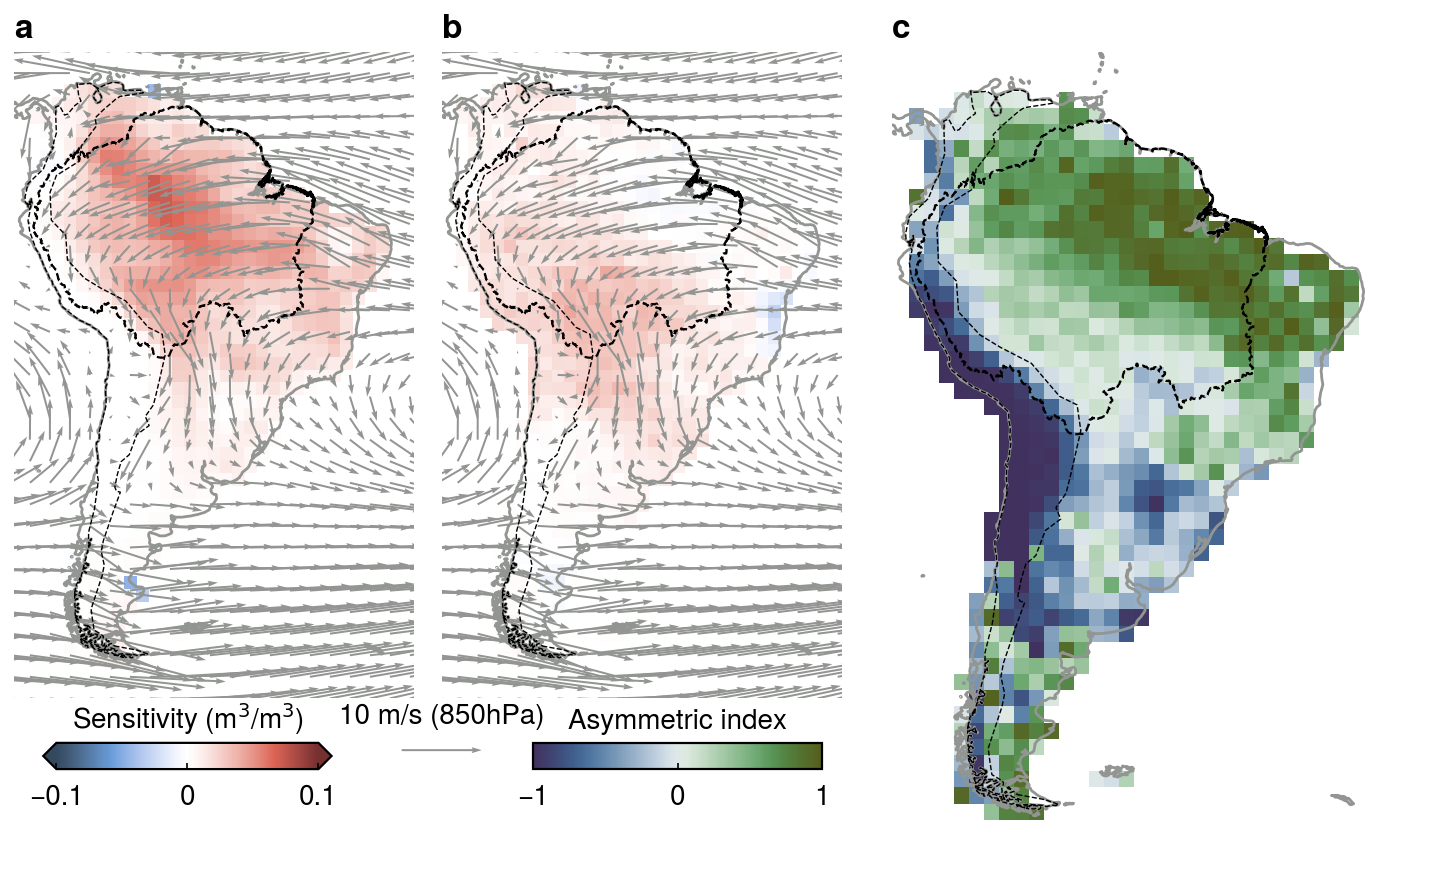

In [27]:
# Define PlateCarree projection for geographic coordinates
proj = ccrs.PlateCarree()

# Define subplot arrangement matrix
arrray = [  # the "picture" (0 == nothing, 1 == subplot A, 2 == subplot B, etc.)
    [1, 2, 3],
    [0, 0, 3]
]

# Create figure with specified width and layout settings
fig = uplt.figure(refwidth=2, share=False, span=False, tight=True)

# Create subplots with specified arrangement, projection, and size ratios
axs = fig.subplots(arrray, projection=proj, abc=True, width_ratios=[1, 1, 1.5], height_ratios=[4,1])

# Format axes with longitude and latitude limits
axs.format(lonlim=lonlim, latlim=latlim, linewidth=0)

################################################
# First subplot: Sender sensitivity visualization
ax = axs[0]

# Create colored mesh plot for sender sensitivity values
im = ax.pcolormesh(
    da_send.lon,
    da_send.lat,
    da_send.values,
    cmap='negpos',  # Colormap for positive/negative values
    discrete=False,
    transform=ccrs.PlateCarree(),  # Coordinate transformation
    vmin=-0.1, vmax=0.1,  # Color scale limits
)

# Plot Amazon border as dashed line
amazon_border.plot(ax=ax, linewidth=0.8, color='none', linestyle='--', zorder=50)

# Plot Andes region border
geography_vector[geography_vector['NAME']=='ANDES'].plot(ax=ax, linewidth=0.5, color='none', linestyle='--', zorder=50, ec='k')

# Add coastline feature
ax.add_feature(cfeature.COASTLINE, edgecolor='grey', linewidth=1)

# Add colorbar for sender sensitivity
cax = fig.add_axes([0.03, 0.12, 0.2, 0.03], title='Sensitivity (m${^3}$/m${^3}$)', titlesize=10)
fig.colorbar(
    im,
    cax=cax,
    orientation='horizontal',
    extend='both',  # Extend both ends for out-of-range values
    ticks=[-0.1, 0, 0.1],
)

# Add wind vector arrows (quiver plot)
qv = ax.quiver(pu0.longitude, pu0.latitude, pu0, pv0, transform=ccrs.PlateCarree(),vmin=0,vmax=15,color='grey',
               scale=50,  # Adjust arrow size (smaller value = larger arrows)
               width=0.005,)  # Arrow width

################################################
# Second subplot: Receiver sensitivity visualization
ax = axs[1]

# Create colored mesh plot for receiver sensitivity values
im = ax.pcolormesh(
    da_rec.lon,
    da_rec.lat,
    da_rec.values,
    cmap='negpos',
    discrete=False,
    transform=ccrs.PlateCarree(),
    vmin=-0.1, vmax=0.1,
)

# Plot Amazon and Andes borders
amazon_border.plot(ax=ax, linewidth=0.8, color='none', linestyle='--', zorder=50)
geography_vector[geography_vector['NAME']=='ANDES'].plot(ax=ax, linewidth=0.5, color='none', linestyle='--', zorder=50, ec='k')

# Add coastline
ax.add_feature(cfeature.COASTLINE, edgecolor='grey', linewidth=1)

# Add wind vectors
qv = ax.quiver(pu0.longitude, pu0.latitude, pu0, pv0, transform=ccrs.PlateCarree(),vmin=0,vmax=15,color='grey',
               scale=50,
               width=0.005,)

# Add wind speed reference key
handles = [ax.quiverkey(qv, 0., -0.08, 10, label='10 m/s (850hPa)', labelpos='N'),]

################################################
# Third subplot: Asymmetric metric visualization
ax = axs[2]

# Create colored mesh plot for asymmetric metric values
im = ax.pcolormesh(
    da_metric.lon,
    da_metric.lat,
    da_metric.values,
    cmap='cork',  # Different colormap for metric
    discrete=False,
    transform=ccrs.PlateCarree(),
    alpha=0.9,  # Semi-transparent
    vmin=-1, vmax=1,  # Full range metric scale
)

# Plot Amazon and Andes borders
amazon_border.plot(ax=ax, linewidth=0.8, color='none', linestyle='--', zorder=50)
geography_vector[geography_vector['NAME']=='ANDES'].plot(ax=ax, linewidth=0.5, color='none', linestyle='--', zorder=50, ec='k')

# Add coastline
ax.add_feature(cfeature.COASTLINE, edgecolor='grey', linewidth=1)

# Add colorbar for asymmetric metric
cax = fig.add_axes([0.37, 0.12, 0.2, 0.03], title='Asymmetric index', titlesize=10)
fig.colorbar(
    im,
    cax=cax,
    orientation='horizontal',
    extend='neither',  # No extension for full range metric
    ticks=[-1, 0, 1],
)

In [33]:
import numpy as np
from scipy.stats import binomtest, ttest_rel

def generate_c_with_significance(a, b, threshold=0.1, ratio_threshold=10, alpha=0.05):
    """
    Generate relationship matrix c and calculate significance p-values for each case.
    
    Parameters:
        a, b: Arrays of shape (733, 216) containing values to compare
        threshold: Relative error threshold for determining "a ≈ b" (default 0.1)
        ratio_threshold: Ratio threshold for determining ">>" or "<<" relationships (default 2)
        alpha: Significance level for statistical tests (default 0.05)
    
    Returns:
        c: Relationship matrix (733, 216) with values 1-8 representing different relationship types
        p: p-value matrix (733, 216) containing statistical significance values
        is_significant: Boolean matrix (733, 216) indicating statistically significant relationships
    """
    # Initialize output matrices
    c = np.zeros_like(a, dtype=int)  # Relationship type matrix
    p = np.ones_like(a)  # Default p=1 (not significant)
    is_significant = np.zeros_like(a, dtype=bool)  # Significance flag matrix
    
    # Precompute absolute values and ratios for comparison
    abs_a, abs_b = np.abs(a), np.abs(b)
    sum_abs = 0.5 * (abs_a + abs_b)  # Average magnitude for relative comparisons
    ratio_ab = np.divide(a, b, out=np.zeros_like(a), where=(b!=0))  # a/b ratio with zero division protection
    ratio_ba = np.divide(b, a, out=np.zeros_like(b), where=(a!=0))  # b/a ratio with zero division protection
    
    # Case 1: Both positive, a approximately equals b
    mask = (a > 0) & (b > 0) & ((np.abs(a - b) / (sum_abs + 1e-10)) < threshold)
    c[mask] = 1
    p[mask] = binomtest(np.sum(mask), mask.size, p=0.25).pvalue  # Binomial test for proportion significance
    
    # Case 2: Both negative, a approximately equals b
    mask = (a < 0) & (b < 0) & ((np.abs(a - b) / (sum_abs + 1e-10)) < threshold)
    c[mask] = 2
    p[mask] = binomtest(np.sum(mask), mask.size, p=0.25).pvalue
    
    # Case 3: a positive, b negative (opposite signs)
    mask = (a > 0) & (b < 0)
    c[mask] = 3
    p[mask] = binomtest(np.sum(mask), mask.size, p=0.25).pvalue
    
    # Case 4: a negative, b positive (opposite signs)
    mask = (a < 0) & (b > 0)
    c[mask] = 4
    p[mask] = binomtest(np.sum(mask), mask.size, p=0.25).pvalue
    
    # Case 5: Both positive, a much greater than b (a >> b)
    mask = (a > 0) & (b > 0) & (ratio_ab > ratio_threshold)
    c[mask] = 5
    # Paired t-test for each significant location
    for idx in np.argwhere(mask):
        i, j = idx
        _, p_val = ttest_rel(a[i], b[i] * ratio_threshold, alternative='greater')
        p[i,j] = p_val
    
    # Case 6: Both positive, a much less than b (a << b)
    mask = (a > 0) & (b > 0) & (ratio_ba > ratio_threshold)
    c[mask] = 6
    for idx in np.argwhere(mask):
        i, j = idx
        _, p_val = ttest_rel(b[i], a[i] * ratio_threshold, alternative='greater')
        p[i,j] = p_val
    
    # Case 7: Both negative, |a| much greater than |b| (effectively a << b)
    mask = (a < 0) & (b < 0) & (abs_a / (abs_b + 1e-10) > ratio_threshold)
    c[mask] = 7
    for idx in np.argwhere(mask):
        i, j = idx
        _, p_val = ttest_rel(abs_a[i], abs_b[i] * ratio_threshold, alternative='greater')
        p[i,j] = p_val
    
    # Case 8: Both negative, |a| much less than |b| (effectively a >> b)
    mask = (a < 0) & (b < 0) & (abs_b / (abs_a + 1e-10) > ratio_threshold)
    c[mask] = 8
    for idx in np.argwhere(mask):
        i, j = idx
        _, p_val = ttest_rel(abs_b[i], abs_a[i] * ratio_threshold, alternative='greater')
        p[i,j] = p_val
    
    # Determine statistical significance based on alpha threshold
    is_significant = p < alpha
    
    return c, p, is_significant

In [45]:
def generate_c_with_significance2(a, b, threshold=0.1, ratio_threshold=2, alpha=0.05):
    # Initialize output arrays: c for case classification, p for p-values
    c = np.zeros_like(a, dtype=int)
    p = np.ones_like(a)
    abs_a, abs_b = np.abs(a), np.abs(b)
    # Calculate relative difference between a and b
    rel_diff = np.abs(a - b) / (0.5 * (abs_a + abs_b) + 1e-10)  # relative difference

    # Cases 1-4: Test significance of a ≈ b using paired t-test
    for case, mask in [
        (1, (a > 0) & (b > 0) & (rel_diff < threshold)),  # both positive and close
        (2, (a < 0) & (b < 0) & (rel_diff < threshold)),  # both negative and close
        (3, (a > 0) & (b < 0)),                          # a positive, b negative
        (4, (a < 0) & (b > 0))                           # a negative, b positive
    ]:
        c[mask] = case
        # Perform paired t-test for a ≈ b significance
        _, p[mask] = ttest_rel(a[mask], b[mask])

    # Cases 5-8: Test magnitude relationships using t-test
    for case, mask in [
        (5, (a > 0) & (b > 0) & (a / b > ratio_threshold)),  # a >> b (positive)
        (6, (a > 0) & (b > 0) & (b / a > ratio_threshold)),  # a << b (positive)
        (7, (a < 0) & (b < 0) & (abs_a / abs_b > ratio_threshold)),  # |a| >> |b| (negative)
        (8, (a < 0) & (b < 0) & (abs_b / abs_a > ratio_threshold))   # |a| << |b| (negative)
    ]:
        c[mask] = case
        # Perform one-sided t-test for magnitude relationships
        for idx in np.argwhere(mask):
            i, j = idx
            if case in [5, 7]:
                # Test if a is significantly greater than scaled b
                _, p[i,j] = ttest_rel(a[i], b[i] * ratio_threshold, alternative='greater')
            else:
                # Test if b is significantly greater than scaled a
                _, p[i,j] = ttest_rel(b[i], a[i] * ratio_threshold, alternative='greater')

    # Determine statistical significance based on alpha threshold
    is_significant = p < alpha
    return c, p, is_significant

In [43]:
ratio, p, sig =generate_c_with_significance(rec, don[:,:,0])

In [46]:
ratio2, p2, sig2 =generate_c_with_significance2(rec, don[:,:,0])

/tmp/ipykernel_4119096/2488464388.py:19: RuntimeWarning: divide by zero encountered in divide
  (5, (a > 0) & (b > 0) & (a / b > ratio_threshold)),  # a >> b
/tmp/ipykernel_4119096/2488464388.py:19: RuntimeWarning: invalid value encountered in divide
  (5, (a > 0) & (b > 0) & (a / b > ratio_threshold)),  # a >> b
/tmp/ipykernel_4119096/2488464388.py:20: RuntimeWarning: divide by zero encountered in divide
  (6, (a > 0) & (b > 0) & (b / a > ratio_threshold)),  # a << b
/tmp/ipykernel_4119096/2488464388.py:20: RuntimeWarning: invalid value encountered in divide
  (6, (a > 0) & (b > 0) & (b / a > ratio_threshold)),  # a << b
/tmp/ipykernel_4119096/2488464388.py:21: RuntimeWarning: divide by zero encountered in divide
  (7, (a < 0) & (b < 0) & (abs_a / abs_b > ratio_threshold)),  # |a| >> |b|
/tmp/ipykernel_4119096/2488464388.py:21: RuntimeWarning: invalid value encountered in divide
  (7, (a < 0) & (b < 0) & (abs_a / abs_b > ratio_threshold)),  # |a| >> |b|
/tmp/ipykernel_4119096/24884643

In [56]:
np.save('/Net/Groups/BGI/scratch/fhuang/sm_utb_cnn/model/c3d-gam/567_568_569/asymmetry_ratio2.npy',ratio2)
np.save('/Net/Groups/BGI/scratch/fhuang/sm_utb_cnn/model/c3d-gam/567_568_569/asymmetry_p2.npy',p2)
np.save('/Net/Groups/BGI/scratch/fhuang/sm_utb_cnn/model/c3d-gam/567_568_569/asymmetry_sig2.npy',sig2)